# Mass mapping with uncertainty quantification
*Notebook reproducing the results from Leterme, H. Leterme, A. Tersenov, J. Fadili, and J.-L. Starck, “A plug-and-play approach with fast uncertainty quantification for weak lensing mass mapping,” Oct. 2025.*

In [1]:
%config InlineBackend.figure_format = 'svg'
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import deepinv as dinv

import wlmmuq as wl
import wlmmuq.data.kappatng as wlktng
import wlmmuq.data.torch as wlds
import wlmmuq.data.cosmos as wlcosmos
import wlmmuq.models.torch as wlnn
import wlmmuq.models.deepinv.iterativemm as wlpnp
import wlmmuq.utils as wlutils

/local/home/hl285110/Documents/Code/venv/wlmmuq/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/local/home/hl285110/Documents/Code/venv/wlmmuq/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. 

Configuration file found in /local/home/hl285110/.config/wlmmuq


/local/home/hl285110/Documents/Code/venv/wlmmuq/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
model_dir = wl.MODEL_DIR
path_to_test_dataset = wl.PATH_TO_TEST_DATASET
path_to_ps = wl.PATH_TO_PS
path_to_std_noise = wl.PATH_TO_STD_NOISE
path_to_mask = wl.PATH_TO_MASK
path_to_extent = wl.PATH_TO_EXTENT

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [5]:
nimgs_test = 512
batch_size = 32
imgsize = 384

# For imshow
imgsize_imshow = 304
vmin = -0.04
vmax = 0.29
vmax_gamma = 0.14
om = 1
idx = 0 # Index of the image to display

## Load noise standard deviation and noise

Diagonal elements of $\Sigma$ and masked pixels.

The noise standard deviation has been obtained by binning the COSMOS shape galaxy catalog (https://www.aanda.org/articles/aa/abs/2010/08/aa13577-09/aa13577-09.html) at a resolution of $0.29$ arcmin per pixel, to match the $\kappa$-TNG dataset of simulated convergence maps (https://academic.oup.com/mnras/article/502/4/5593/6133466).

The noise standard deviation is given, for each pixel $k$, by 
\begin{equation}
    \sigma_k = \frac{\sigma_{\text{ell}}}{\sqrt{N_k}},
\end{equation}
where $\sigma_{\text{ell}}$ denotes the intrinsic shape dispersion of galaxies, and $N_k$ denotes the number of measured galaxies.

In [6]:
cat_cosmos_bright, _ = wlcosmos.cosmos_catalog()
cat_cosmos_bright = wlcosmos.filter_by_redshifts(cat_cosmos_bright, wlktng.MAX_Z)
data_dict = wlktng.get_data_from_cosmos_ktng(cat_cosmos_bright, imgsize)

extent = torch.tensor(data_dict["extent"]) # For imshow
shapedisp = data_dict["shapedisp"] # Intrinsic shape dispersion
ngal = data_dict["ngal"] # Number of galaxies per pixel
mask = data_dict["mask"] # Mask

std_noise = wlutils.get_std_noise(ngal, shapedisp, std_noise_mask=0) # Noise standard deviation

In [7]:
# Alternatively, load precomputed data (uncomment the following lines)
# std_noise = torch.load(path_to_std_noise)
# mask = torch.load(path_to_mask)
# extent = torch.load(path_to_extent)

In [8]:
ra, dec = np.array(wlcosmos.COSMOS_VERTICES).T # Survey boundaries

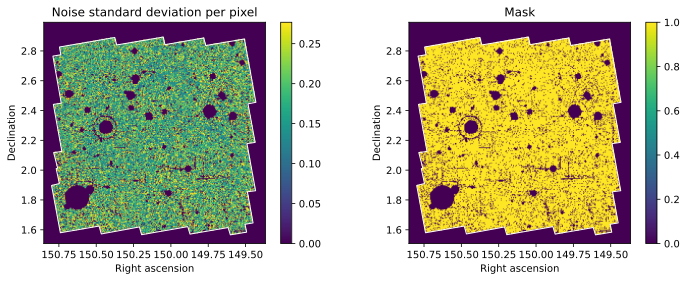

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
wlutils.skyshow(
    std_noise, imgsize=imgsize_imshow,
    boundaries=(ra, dec), extent=extent
)
plt.title("Noise standard deviation per pixel")
plt.subplot(122)
wlutils.skyshow(
    mask, imgsize=imgsize_imshow,
    boundaries=(ra, dec), extent=extent
)
plt.title("Mask")
plt.show()

## Run mass mapping with CQR

Execute the following bash commands from the root of the repository.
Please refer to the documentation of each Python script for more information.

### Wiener

```bash
python scripts/wiener.py --cqr -w 8 --save-tensors -o results_wiener_cqr --seed 42 -v
```

### MCALens

```bash
python scripts/mcalens.py -thresh 4.5 -alph 0.5 -i 16 --cqr -w 8 --save-tensors -o results_mcalens_starlet-detection-threshold_4.5_niter_16_cqr --seed 42 -v
```

### DeepMass

```bash
python scripts/deepmass.py -c deepmass_arch_UNetPreproc_mode-preproc_wiener_nepochs_20 -a UNetPreproc -m wiener -t 20250613_142121 -e 20 -uq -t0 20250917_153127 -e0 100 --cqr --find-optimal-hyperparam-precalib -w 8 --save-tensors -o results_deepmass_epoch_20_epoch-uq_100_cqr --seed 42 -v
```

### PnPMass

```bash
python scripts/pnpmass.py -c denoiser_arch_SUNetNoiseAware_scale_0.2_scale-min_0.0_batch-size_16_nepochs_100_learning-rate_1e-3 -a SUNetNoiseAware -t 20250613_143319 -uq -t0 20250903_164013 -i 8 --cqr --find-optimal-hyperparam-precalib -w 8 --save-tensors -o results_pnpmass_niter_8_cqr --seed 42 -v
```

### PnPMass (residual version)

```bash
python scripts/pnpmass.py -c denoiser_arch_SUNetNoiseAware_nongaussian_scale_0.2_scale-min_0.0_batch-size_16_nepochs_100_learning-rate_1e-3 -a SUNetNoiseAware -t 20250716_170944 --mode residual -uq -t0 20250903_164205 -i 8 --cqr --find-optimal-hyperparam-precalib -w 8 --save-tensors -o results_pnpmass_mode_residual_niter_8_cqr --seed 42 -v
```

## Load results

In [10]:
listof_configname = [
    "Wiener",
    "MCALens",
    "DeepMass",
    "PnPMass",
    "PnPMass (res.)",
]

listof_dirname = [
    "wiener",
    "mcalens",
    "deepmass_arch_UNetPreproc_mode-preproc_wiener_nepochs_20",
    (
        "denoiser_arch_SUNetNoiseAware_scale_0.2_scale-min_0.0_"
        "batch-size_16_nepochs_100_learning-rate_1e-3"
    ),
    (
        "denoiser_arch_SUNetNoiseAware_nongaussian_scale_0.2_scale-min_0.0_"
        "batch-size_16_nepochs_100_learning-rate_1e-3"
    ),
]

listof_timestamp_pe = [
    None, None,
    "20250613_142121",
    "20250613_143319",
    "20250716_170944",
]
listof_nepochs_pe = [
    None, None, 20, 100, 100
]

listof_timestamp_uq = [
    None, None,
    "20250917_153127",
    "20250903_164013",
    "20250903_164205",
]
listof_nepochs_uq = [
    None, None, 100, 100, 100
]

In [11]:
listof_filename_results = [
    (
        "results_wiener_cqr_20251017_150003.pt"
    ),
    (
        "results_mcalens_starlet-detection-threshold_4.5_"
        "niter_16_cqr_step-size_0.088_20251017_150548.pt"
    ),
    (
        "results_deepmass_epoch_20_epoch-uq_100_cqr_20251017_150702.pt"
    ),
    (
        "results_pnpmass/results_pnpmass_"
        "niter_8_cqr_step-size_0.176_20251017_151012.pt"
    ),
    (
        "results_pnpmass/results_pnpmass_mode_residual_"
        "niter_8_cqr_step-size_0.176_20251017_151138.pt"
    ),
]

In [12]:
listof_path_to_saved_results = [
    os.path.join(
        model_dir,
        dirname,
        filename
    ) for dirname, filename in zip(listof_dirname, listof_filename_results)
]
listof_results = [
    torch.load(path_to_saved_results, map_location="cpu", weights_only=False) \
        for path_to_saved_results in listof_path_to_saved_results
]

FileNotFoundError: [Errno 2] No such file or directory: '/local/home/hl285110/Documents/Models/kappaTNG/wiener/results_wiener_cqr_20251017_150003.pt'

In [ ]:
listof_nrmse = []
listof_l2norm = []
for configname, results in zip(listof_configname, listof_results):
    rmse = results["rmse"]
    try:
        l2norm = results["l2norm"]
    except KeyError:
        l2norm = results["rl2norm"]
    if rmse.ndim > 1: # Shape = (nimgs, niter)
        rmse = rmse[:, -1] # Last iteration
    nrmse = rmse / l2norm
    listof_nrmse.append(nrmse)
    listof_l2norm.append(l2norm)
    print(f"{configname}:")
    print(f"\tRMSE = {rmse.mean():.3e} +/- {rmse.std():.3e}")
    print(f"\tNRMSE = {nrmse.mean():.3e} +/- {nrmse.std():.3e}")

In [ ]:
for configname, results in zip(listof_configname, listof_results):
    print(f"{configname}:")
    print(f"\tInference time = {results['inference_time']:.1f} secs")
    print(f"\tCalibration time = {results['calibration_time']:.1f} secs")